# Penguin Species Classification with a Neural Network

This notebook is based on [episode 2](https://carpentries-lab.github.io/deep-learning-intro/2-keras.html) and walks through the full deep-learning workflow, from raw data to a trained classifier, using the Palmer Penguins dataset and a small fully-connected network.

> **Platform:** Tested on **UCL's Unified AI Platform** (5 CPUs, 64 GB RAM). Runs in any standard environment with the required dependencies installed.

> **Support:** Contact [ARC.Collaborations@ucl.ac.uk](mailto:ARC.Collaborations@ucl.ac.uk) for help with AI platforms, GPUs, or Carpentries training.

---

| Shortcut | Action |
|---|---|
| `Shift + Enter` | Run current cell, move to next |
| `Alt + Enter` | Run current cell, insert new cell below |
| `Ctrl + Shift + F9` | Restart kernel and run all cells |

## 1. System Information

Capture the runtime environment for reproducibility.

In [2]:
import sys, platform
from datetime import datetime

print(f"Date/Time : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python    : {sys.version}")
print(f"Platform  : {platform.platform()}")
print(f"Machine   : {platform.machine()}")

Date/Time : 2026-05-28 21:01:44
Python    : 3.11.10 | packaged by conda-forge | (main, Sep 30 2024, 18:08:57) [GCC 13.3.0]
Platform  : Linux-5.14.0-570.30.1.el9_6.x86_64-x86_64-with-glibc2.35
Machine   : x86_64


## 2. Imports 

All third-party imports are collected here so missing packages surface immediately. Run the install cell at the bottom if any row shows `FAIL`.

In [3]:
# Standard library
import time

# Third-party — data & visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Third-party — ML / DL
import tensorflow
import tensorboard
import sklearn
import keras_tuner
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print("All packages imported successfully.")

I0000 00:00:1780002107.977240 1108590 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All packages imported successfully.


## 3. Load & Explore Data

We use the **Palmer Penguins** dataset, which contains measurements for three penguin species (Adelie, Chinstrap, Gentoo) across several islands. Our goal is to predict species from physical measurements.

In [4]:
penguins = sns.load_dataset('penguins')
print(f"Shape: {penguins.shape}")
penguins.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


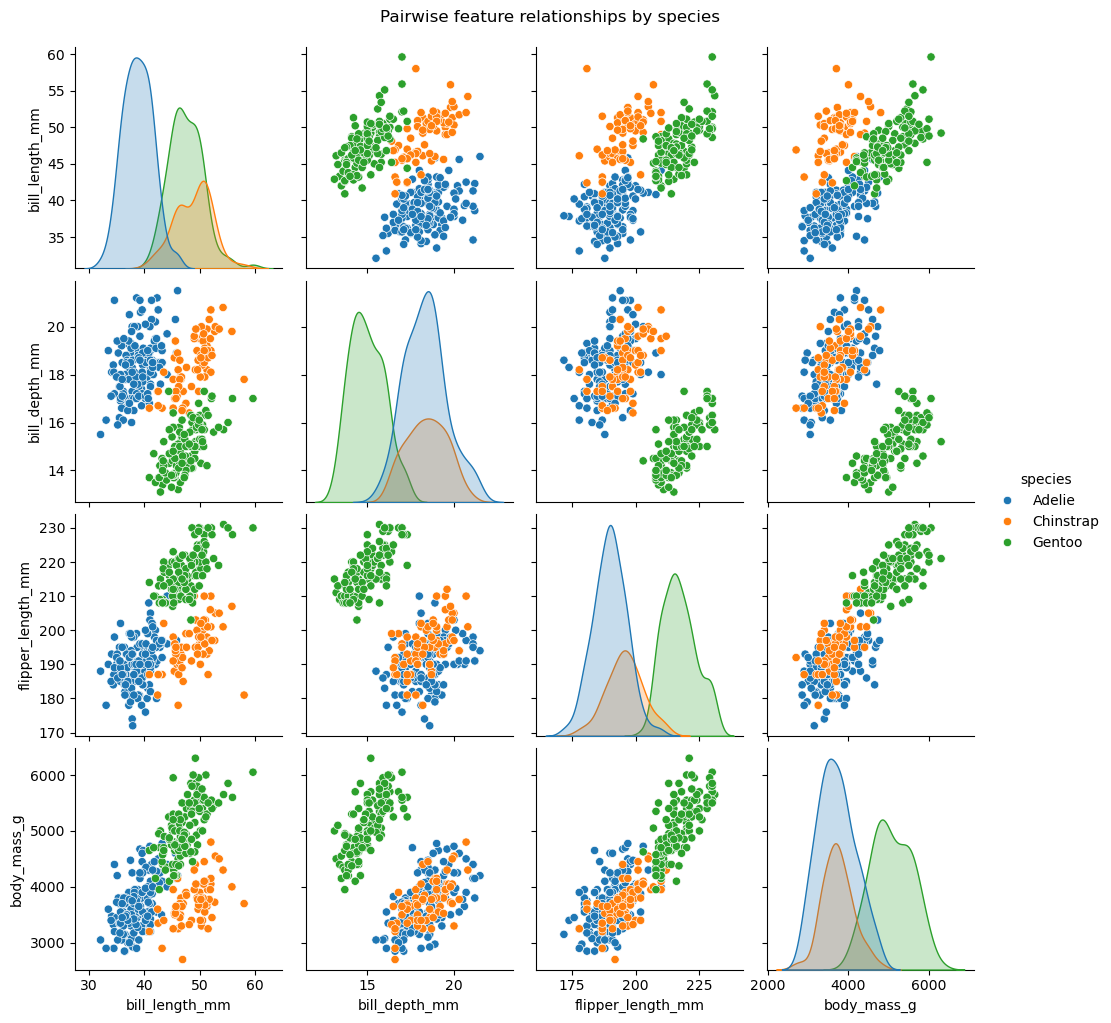

In [5]:
# Visual overview: pairwise feature relationships coloured by species
sns.pairplot(penguins, hue="species")
plt.suptitle("Pairwise feature relationships by species", y=1.02)
plt.show()

## 4. Preprocess Data

Steps:
1. Drop non-numeric columns (`island`, `sex`) that we won't use as features.
2. Remove rows with missing values.
3. One-hot encode the target column (`species`) so the network can output class probabilities.

In [6]:
# Keep only numeric feature columns and drop rows with NaNs
penguins_filtered = (
    penguins
    .drop(columns=['island', 'sex'])
    .dropna()
)

features = penguins_filtered.drop(columns=['species'])
print(f"Feature matrix shape: {features.shape}")

Feature matrix shape: (342, 4)


In [7]:
# One-hot encode the species labels
# e.g. 'Adelie' -> [1, 0, 0],  'Chinstrap' -> [0, 1, 0],  'Gentoo' -> [0, 0, 1]
target = pd.get_dummies(penguins_filtered['species'])
target.head()

,Adelie,Chinstrap,Gentoo
0,True,False,False
1,True,False,False
2,True,False,False
4,True,False,False
5,True,False,False


In [8]:
# Stratified split ensures each species is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    stratify=target
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (273, 4)  |  Test: (69, 4)


## 5. Build the Model

Architecture: `Input(4) → Dense(10, ReLU) → Dense(3, Softmax)`

- **ReLU** in the hidden layer introduces non-linearity.
- **Softmax** in the output layer converts raw scores to class probabilities that sum to 1.

In [9]:
# Fix the random seed so results are reproducible across runs
keras.utils.set_random_seed(2)

inputs      = keras.Input(shape=(X_train.shape[1],))
hidden      = keras.layers.Dense(units=10, activation="relu")(inputs)
outputs     = keras.layers.Dense(units=3,  activation="softmax")(hidden)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

E0000 00:00:1780002151.580310 1108590 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

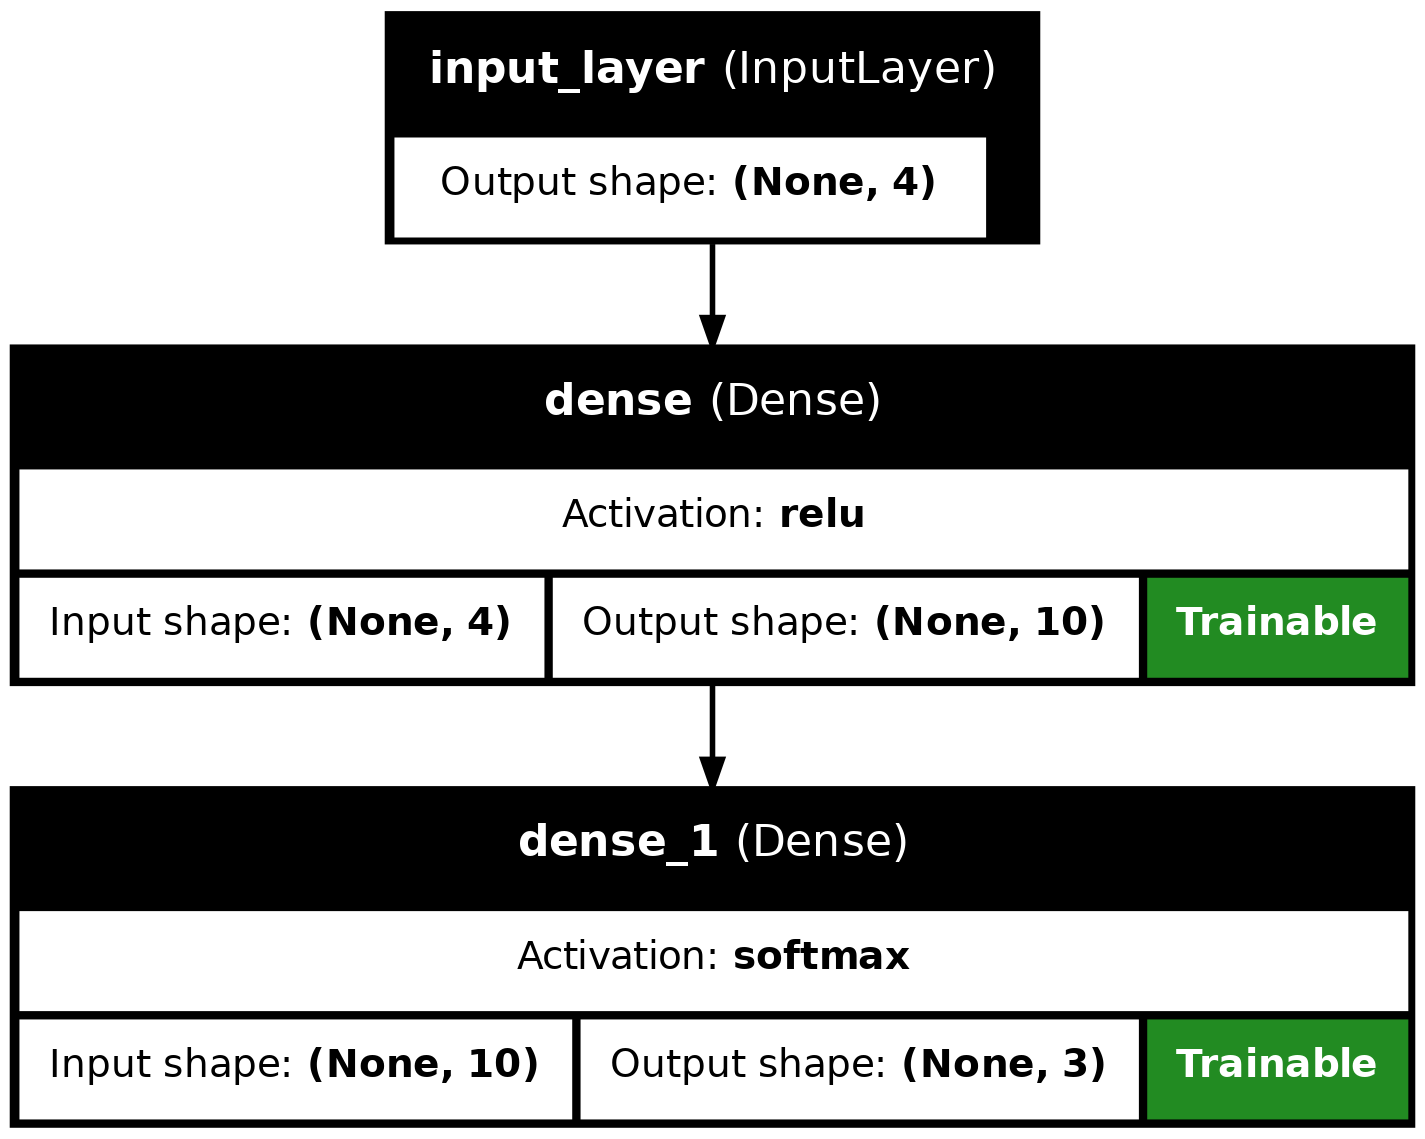

In [10]:
# Visualise the graph (requires graphviz / pydot to be installed)
keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True,
)

## 6. Compile & Train

We use **categorical cross-entropy** as the loss (standard for multi-class classification) and the **Adam** optimiser.

In [11]:
model.compile(
    optimizer='adam',
    loss=keras.losses.CategoricalCrossentropy()
)

In [12]:
start_time = time.time()

history = model.fit(X_train, y_train, epochs=100)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 623.0577  
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 519.2202 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 413.6821 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 305.6798 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 206.9116 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 130.0824 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 57.9688  
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.3862 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.9243 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.3335 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.8973 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.6442 
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.9737 
Epoch 14/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.2201 
Epoch 15/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.50

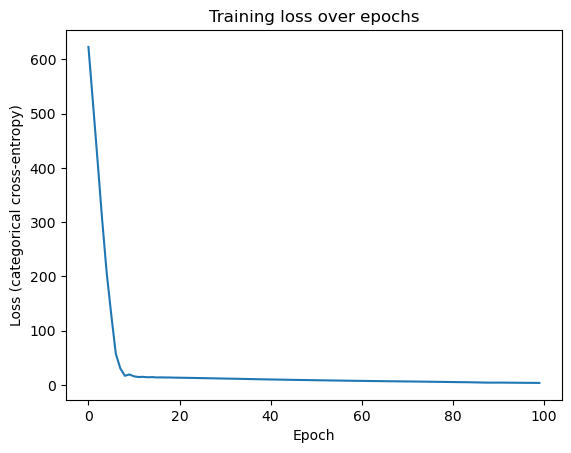

In [13]:
# Plot training loss curve
sns.lineplot(x=history.epoch, y=history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss (categorical cross-entropy)")
plt.title("Training loss over epochs")
plt.show()

## 7. Evaluate the Model

We predict on the held-out test set and compare predicted vs. true species using a **confusion matrix**.

In [14]:
y_pred = model.predict(X_test)
prediction = pd.DataFrame(y_pred, columns=target.columns)
predicted_species = prediction.idxmax(axis="columns")
true_species      = y_test.idxmax(axis="columns")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


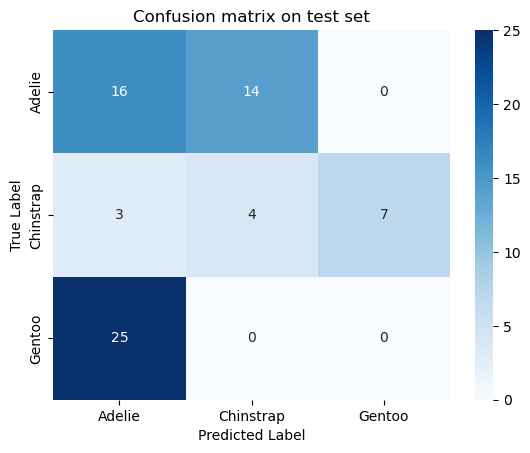

In [15]:
# Build and display the confusion matrix as a labelled heatmap
matrix       = confusion_matrix(true_species, predicted_species)
confusion_df = pd.DataFrame(matrix,
                             index=y_test.columns.values,
                             columns=y_test.columns.values)
confusion_df.index.name   = 'True Label'
confusion_df.columns.name = 'Predicted Label'

sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion matrix on test set")
plt.show()

## 8. Save & Load Model (Optional)

Uncomment and run to persist the trained model to disk and reload it for later inference.

In [16]:
# Save the trained model
# model.save('my_first_model.keras')

# Load and run inference with the saved model
# pretrained_model = keras.models.load_model('my_first_model.keras')
# y_pretrained_pred = pretrained_model.predict(X_test)
# pretrained_prediction = pd.DataFrame(y_pretrained_pred, columns=target.columns.values)
# pretrained_predicted_species = pretrained_prediction.idxmax(axis="columns")
# print(pretrained_predicted_species)

## References

- Course: [Introduction to Deep Learning (Carpentries)](https://carpentries-lab.github.io/deep-learning-intro/)
- [`pandas.get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)
- [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [Keras metrics API](https://keras.io/api/metrics/)